In [1]:
import torchvision
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import lightning as L
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping
from lightning.pytorch.loggers import TensorBoardLogger
from enum import Enum
import json
from lightning.pytorch.loggers import CSVLogger
from lightning.pytorch.callbacks import TQDMProgressBar

In [2]:
import spoofdet.config as config
from spoofdet.efficient_net.model_utils import check_dataset_distribution, display_train_result, analyze_spoof_types, analyze_dataset_spoof_distribution, display_params, verify_subject_split, get_data_for_training
from spoofdet.train import train_model
from spoofdet.evaluate import evaluate_model
from spoofdet.data_processing import get_transform_pipeline, create_subset
from spoofdet.utils import check_image, check_augmented_image, save_results
from spoofdet.dataset import CelebASpoofDataset
from spoofdet.efficient_net.model import EfficientNetSpoofingDetection, get_model, freeze_stages, adaptive_batch_norm

In [3]:
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)

In [4]:


PARAM_MULTIPLIER = 1

MODEL_NAME = "efficientnet_v2_s"
BATCH_SIZE = 32 * PARAM_MULTIPLIER


EPOCHS = 50
EARLY_STOPPING_LIMIT = 10
TARGET_SIZE = 320  # 320
# TARGET_SIZE = config.TARGET_SIZE
LEARNING_RATE = 1e-3 * PARAM_MULTIPLIER

BACKBONE_LR = 1e-5
HEAD_LR = 3e-4


class ModelLR(Enum):
    backbone = BACKBONE_LR
    head = HEAD_LR


WEIGHT_DECAY = 1e-4 * PARAM_MULTIPLIER


NUM_UNFROZEN_LAYERS = 2


WORKERS = 2

SPOOF_PERCENT = 0.5
TRAIN_IMG_COUNT = 10000
VAL_IMG_COUNT = int(TRAIN_IMG_COUNT * 0.2)
# VAL_IMG_COUNT = 1000
TEST_IMG_COUNT = int(TRAIN_IMG_COUNT * 0.1)
# 0.001

In [5]:
train_dict, val_dict = get_data_for_training(
    str(config.TRAIN_JSON), train_count=TRAIN_IMG_COUNT, val_count=VAL_IMG_COUNT)


train_ds = CelebASpoofDataset(
    root_dir=config.ROOT_DIR,
    json_label_path=train_dict,
    bbox_json_path=config.BBOX_LOOKUP,
    target_size=TARGET_SIZE,
    bbox_original_size=config.BBOX_ORGINAL_SIZE
)

val_ds = CelebASpoofDataset(
    root_dir=config.ROOT_DIR,
    json_label_path=val_dict,
    bbox_json_path=config.BBOX_LOOKUP,
    target_size=TARGET_SIZE,
    bbox_original_size=config.BBOX_ORGINAL_SIZE
)

test_ds = CelebASpoofDataset(
    root_dir=config.ROOT_DIR,
    json_label_path=config.TEST_JSON,
    bbox_json_path=config.BBOX_LOOKUP,
    target_size=TARGET_SIZE,
    bbox_original_size=config.BBOX_ORGINAL_SIZE,
)

Total training images: 494405
Subjects: 8192 total, 6553 train, 1639 val
Images: 395427 train, 98978 val
Subject-split - Train: 395427 Val: 98978
Training set: 10000 images
  Live: 5000 (50.0%)
  Spoof: 5000 (50.0%)
Validation set: 2000 images
  Live: 1000 (50.0%)
  Spoof: 1000 (50.0%)
Loading BBox Cache into RAM...
Loading BBox Cache into RAM...
Loading BBox Cache into RAM...


In [6]:

# # np.random.seed(seed)

# # small_train_ds = create_subset(train_ds, total_size=TRAIN_IMG_COUNT, spoof_percent=SPOOF_PERCENT)
# # small_val_ds = create_subset(val_ds, total_size=VAL_IMG_COUNT, spoof_percent=SPOOF_PERCENT)
small_test_ds = create_subset(test_ds, total_size=TEST_IMG_COUNT)
# # print(f"Created Balanced Train: {len(small_train_ds)} images")

 Scanning specific indices for class balance...
 Found in this split: 19923 Live | 47247 Spoof


In [7]:
from torch.utils.data import DataLoader
small_train_loader = DataLoader(train_ds,
                                batch_size=BATCH_SIZE,
                                shuffle=True,
                                num_workers=WORKERS,
                                pin_memory=True,
                                persistent_workers=True,
                                drop_last=True


                                )
small_val_loader = DataLoader(val_ds,
                              batch_size=BATCH_SIZE,
                              shuffle=False,
                              num_workers=WORKERS,
                              pin_memory=True,
                              persistent_workers=True


                              )
small_test_loader = DataLoader(small_test_ds,
                               batch_size=BATCH_SIZE,
                               shuffle=False,
                               num_workers=WORKERS,
                               pin_memory=True,
                               persistent_workers=True
                               )

In [8]:
device = torch.device("cpu")

In [9]:
model_path = "tb_logs/efficientnet_v2_s/version_31/checkpoints/epoch=16-step=5304.ckpt"
model = EfficientNetSpoofingDetection.load_from_checkpoint(model_path, strict=False)
model.to(device)
model.eval()
# model.freeze()
# script = model.to_torchscript()
# torch.jit.save(script, "model.pt")

quantize_model = model

d:\JoshFile\Github\spoofing-recognition\.venv\Lib\site-packages\lightning\pytorch\core\saving.py:197: Found keys that are not in the model state dict but in the checkpoint: ['criterion.pos_weight']


In [11]:
import warnings
from torchvision.models import efficientnet_b0
from torch.ao.quantization import quantize_fx
import os
import torch


# 1. Silence the noise
# This function is stable and correct for CNNs, even if Pylance complains.
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# Import strictly from the .ao namespace (sometimes helps with Pylance)


def get_real_quantized_size():
    # Load
    model = efficientnet_b0(weights='DEFAULT')
    model.eval()

    # Define Config
    # 'fbgemm' for Server (x86), 'qnnpack' for Mobile (ARM)
    qconfig_dict = {"": torch.ao.quantization.get_default_qconfig("fbgemm")}

    # Prepare (Trace & Fuse)
    example_inputs = (torch.randn(1, 3, 320, 320),)
    model_prepared = quantize_fx.prepare_fx(model, qconfig_dict, example_inputs)

    # Calibrate (Crucial for size reduction!)
    print("Calibrating...")
    with torch.no_grad():
        # In real code, use ~50 images from your validation set
        for _ in range(10):
            model_prepared(torch.randn(1, 3, 224, 224))

    # Convert
    model_quantized = quantize_fx.convert_fx(model_prepared)

    # Check Size
    torch.save(model_quantized.state_dict(), "temp_quant_fx.pth")
    size_mb = os.path.getsize("temp_quant_fx.pth") / 1e6
    print(f"Final Quantized Size: {size_mb:.2f} MB")

    # Clean up
    os.remove("temp_quant_fx.pth")


get_real_quantized_size()

C:\Users\Josh\AppData\Local\Temp\ipykernel_9432\3976833710.py:27: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  model_prepared = quantize_fx.prepare_fx(model, qconfig_dict, example_inputs)


Calibrating...


C:\Users\Josh\AppData\Local\Temp\ipykernel_9432\3976833710.py:37: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  model_quantized = quantize_fx.convert_fx(model_prepared)


Final Quantized Size: 6.07 MB


In [12]:
train_transform, val_transforms = get_transform_pipeline(
    device=device, target_size=TARGET_SIZE)

In [13]:
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

qconfig_dict = {"": torch.ao.quantization.get_default_qconfig("fbgemm")}


example_input = torch.randn(1, 3, TARGET_SIZE, TARGET_SIZE)


model_prepared = quantize_fx.prepare_fx(
    quantize_model, qconfig_dict, example_input)  # type: ignore
model_prepared.to(device)
print("Calibrating...")

with torch.no_grad():
    # In real code, use ~50 images from your validation set
    for i, (img, label) in enumerate(small_val_loader):
        if i >= 50:
            break
        img = img.to(device)
        img = val_transforms(img)
        model_prepared(img)

# Convert
model_quantized = quantize_fx.convert_fx(model_prepared)  # type: ignore

# Check Size
torch.save(model_quantized.state_dict(), "temp_quant_fx.pth")
size_mb = os.path.getsize("temp_quant_fx.pth") / 1e6
print(f"Final Quantized Size: {size_mb:.2f} MB")

# Clean up
# os.remove("temp_quant_fx.pth")

C:\Users\Josh\AppData\Local\Temp\ipykernel_9432\701796721.py:10: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  model_prepared = quantize_fx.prepare_fx(


Calibrating...


C:\Users\Josh\AppData\Local\Temp\ipykernel_9432\701796721.py:25: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  model_quantized = quantize_fx.convert_fx(model_prepared)  # type: ignore


Final Quantized Size: 23.04 MB


In [28]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Evaluate quantized model on test set
model_quantized.to(device)
model_quantized.eval()

test_predictions = []
test_labels = []
threshold = 0.9993
with torch.no_grad():
    for i, (img, label) in enumerate(small_test_loader):
        img = img.to(device)
        img = val_transforms(img)

        outputs = model_quantized(img)
        predictions = torch.sigmoid(outputs).squeeze()
        predictions = (predictions > threshold).long()

        test_predictions.extend(predictions.cpu().numpy())
        test_labels.extend(label.numpy())

# Calculate metrics

accuracy = accuracy_score(test_labels, test_predictions)
precision = precision_score(test_labels, test_predictions, zero_division=0)
recall = recall_score(test_labels, test_predictions, zero_division=0)
f1 = f1_score(test_labels, test_predictions, zero_division=0)
cm = confusion_matrix(test_labels, test_predictions)

print(f"Quantized Model Test Results:")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"\nConfusion Matrix:\n{cm}")

Quantized Model Test Results:
Accuracy:  0.8990
Precision: 0.9272
Recall:    0.8660
F1 Score:  0.8956

Confusion Matrix:
[[466  34]
 [ 67 433]]


In [30]:
dummy_input = torch.randn(1, 3, 320, 320)
traced_model = torch.jit.trace(model_quantized, dummy_input)
torch.jit.save(traced_model, "quantized_model_scripted.pt")

AUC-ROC Score: 0.9669
Optimal Threshold: 0.9993


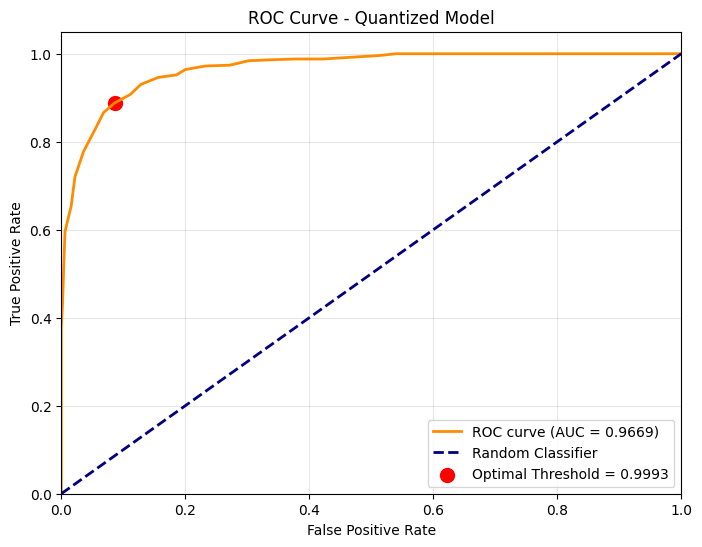

In [25]:
from sklearn.metrics import roc_curve, auc

# Get predictions and labels on full test set
model_quantized.to(device)
model_quantized.eval()

all_predictions = []
all_labels = []

with torch.no_grad():
    for img, label in small_test_loader:
        img = img.to(device)
        img = val_transforms(img)

        outputs = model_quantized(img)
        predictions = torch.sigmoid(outputs).squeeze().cpu().numpy()

        all_predictions.extend(predictions)
        all_labels.extend(label.numpy())

# Calculate ROC curve and AUC
fpr, tpr, thresholds = roc_curve(all_labels, all_predictions)
roc_auc = auc(fpr, tpr)

print(f"AUC-ROC Score: {roc_auc:.4f}")

# Find optimal threshold (Youden's J statistic)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

print(f"Optimal Threshold: {optimal_threshold:.4f}")

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.scatter(fpr[optimal_idx], tpr[optimal_idx], marker='o', color='red',
            s=100, label=f'Optimal Threshold = {optimal_threshold:.4f}')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Quantized Model')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()